# New dataset model analysis

In [1]:
import pandas as pd

DATA_PATH = "../data/student_placement_prediction_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (10000, 15)

Columns:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'communication_skill_score', 'aptitude_score', 'logical_reasoning_score', 'mock_interview_score', 'backlogs', 'placement_status']

First 5 rows:


,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,communication_skill_score,aptitude_score,logical_reasoning_score,mock_interview_score,backlogs,placement_status
0,22,Female,5.49,MECH,2,0,3,2,57,63,67,83,72,0,Placed
1,20,Female,7.07,MECH,2,1,2,1,82,86,40,94,61,0,Not Placed
2,23,Male,5.58,CSE,1,0,1,2,76,68,72,52,82,1,Placed
3,22,Male,9.75,CIVIL,2,1,1,6,74,95,74,66,76,1,Placed
4,18,Male,7.73,EEE,1,2,1,3,76,89,75,53,78,3,Placed


### Separate features and target

In [3]:
# Separate features and target

X = df.drop(columns=["placement_status"])
y = df["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 14)
y shape: (10000,)

Target distribution:
placement_status
Placed        6452
Not Placed    3548
Name: count, dtype: int64


### Train/Test Split


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (8000, 14)
Test set: (2000, 14)

Training target distribution:
placement_status
Placed        0.64525
Not Placed    0.35475
Name: proportion, dtype: float64

Test target distribution:
placement_status
Placed        0.645
Not Placed    0.355
Name: proportion, dtype: float64


### Preprocessing

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


numeric_features = [
    "age",
    "cgpa",
    "college_tier",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "communication_skill_score",
    "aptitude_score",
    "logical_reasoning_score",
    "mock_interview_score",
    "backlogs"
]

categorical_features = [
    "gender",
    "branch"
]


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


print("Preprocessor created successfully.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessor created successfully.
Numeric features: 12
Categorical features: 2


## Train Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Gradient Boosting

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting_pipeline.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


# Evaluate all 3 models

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    # Probability of the positive class: Placed
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, pos_label="Placed"
        ),
        "Recall": recall_score(
            y_test, y_pred, pos_label="Placed"
        ),
        "F1": f1_score(
            y_test, y_pred, pos_label="Placed"
        ),
        "ROC-AUC": roc_auc_score(
            (y_test == "Placed").astype(int),
            y_prob
        )
    })

results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(4))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.645,0.6624,0.9171,0.7692,0.6314
1,Random Forest,0.644,0.6613,0.9186,0.7690,0.6095
2,Gradient Boosting,0.653,0.6648,0.9318,0.7760,0.6174


## Confusion matrices


Logistic Regression
[[ 107  603]
 [ 107 1183]]


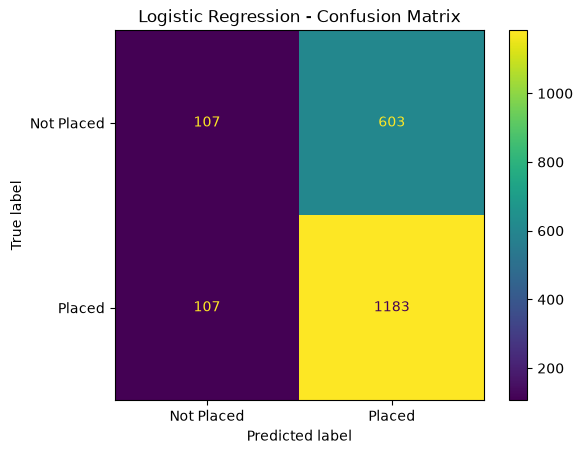


Random Forest
[[ 103  607]
 [ 105 1185]]


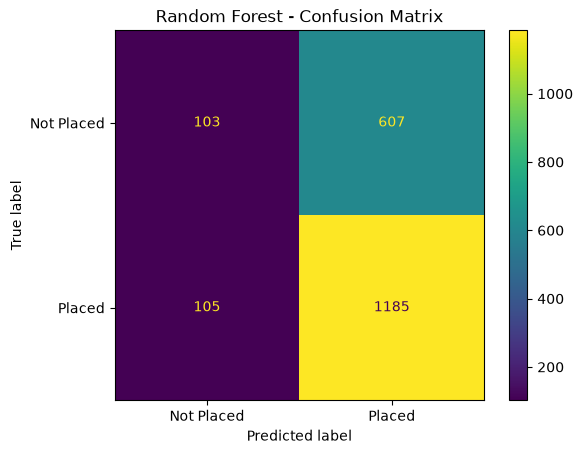


Gradient Boosting
[[ 104  606]
 [  88 1202]]


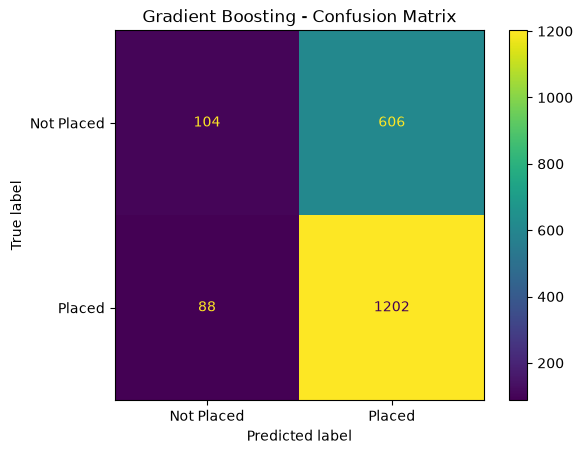

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["Not Placed", "Placed"]
    )

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Placed", "Placed"]
    )

    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

## Check ROC curves

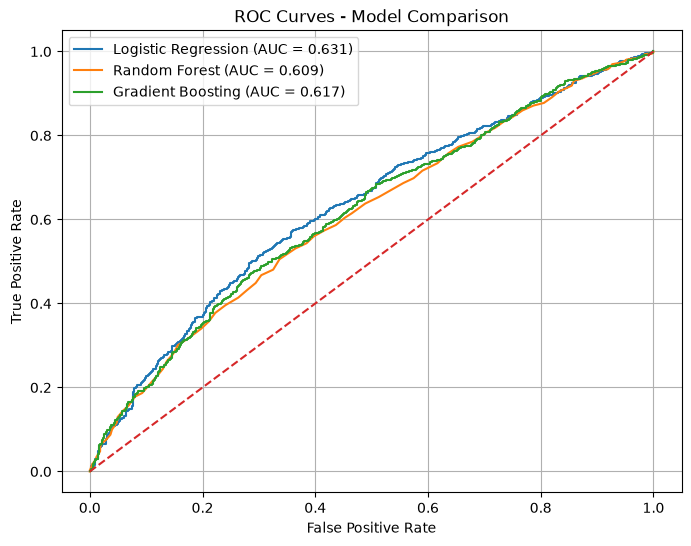

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        (y_test == "Placed").astype(int),
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Threshold analysis

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.40, 0.50, 0.60, 0.70, 0.80]

model = gradient_boosting_pipeline

y_prob = model.predict_proba(X_test)[:, 1]
y_true = (y_test == "Placed").astype(int)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred_threshold),
        "Recall": recall_score(y_true, y_pred_threshold),
        "F1": f1_score(y_true, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1
0,0.4,0.6474,0.9876,0.7821
1,0.5,0.6648,0.9318,0.7760
2,0.6,0.6934,0.7240,0.7084
3,0.7,0.7576,0.4070,0.5295
4,0.8,0.8496,0.0744,0.1368


In [13]:
# Create validation set for threshold tuning

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Final training set:", X_train_final.shape)
print("Validation set:", X_val.shape)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Final training set: (6400, 14)
Validation set: (1600, 14)

Validation target distribution:
placement_status
Placed        0.645
Not Placed    0.355
Name: proportion, dtype: float64


## Retrain Gradient Boosting

In [14]:
gradient_boosting_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting_final.fit(X_train_final, y_train_final)

print("Final Gradient Boosting model trained.")

Final Gradient Boosting model trained.


## Tune threshold using validation set

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict probabilities on validation data only
y_val_prob = gradient_boosting_final.predict_proba(X_val)[:, 1]

y_val_true = (y_val == "Placed").astype(int)

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

validation_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val_true, y_val_pred),
        "Recall": recall_score(y_val_true, y_val_pred),
        "F1": f1_score(y_val_true, y_val_pred)
    })

validation_threshold_df = pd.DataFrame(validation_results)

display(validation_threshold_df.round(4))

,Threshold,Precision,Recall,F1
0,0.40,0.6496,0.9932,0.7854
1,0.45,0.6529,0.9661,0.7792
2,0.50,0.6648,0.9322,0.7761
3,0.55,0.6805,0.8605,0.7599
4,0.60,0.7088,0.7452,0.7265
5,0.65,0.7131,0.5756,0.6370
6,0.70,0.7460,0.4041,0.5242


## Selected threshold based on validation F1

In [16]:
# Selected threshold based on validation F1
BEST_THRESHOLD = 0.40

print("Selected threshold:", BEST_THRESHOLD)
print("Validation F1:", validation_threshold_df.loc[
    validation_threshold_df["Threshold"] == BEST_THRESHOLD, "F1"
].iloc[0])

Selected threshold: 0.4
Validation F1: 0.7854406130268199


## Final evaluation on untouched test set

In [23]:
# Final evaluation on untouched test set
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Get Gradient Boosting model
final_model = models["Gradient Boosting"]

# Probability for "Placed"
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Apply selected threshold
y_test_pred = np.where(
    y_test_proba >= BEST_THRESHOLD,
    "Placed",
    "Not Placed"
)

print("FINAL TEST RESULTS")
print("=" * 50)

print("Threshold:", BEST_THRESHOLD)

print("Accuracy:", round(
    accuracy_score(y_test, y_test_pred), 4
))

print("Precision:", round(
    precision_score(y_test, y_test_pred, pos_label="Placed"), 4
))

print("Recall:", round(
    recall_score(y_test, y_test_pred, pos_label="Placed"), 4
))

print("F1:", round(
    f1_score(y_test, y_test_pred, pos_label="Placed"), 4
))

print("ROC-AUC:", round(
    roc_auc_score(
        (y_test == "Placed").astype(int),
        y_test_proba
    ), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_test_pred,
    labels=["Not Placed", "Placed"]
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Placed", "Placed"]
))

FINAL TEST RESULTS
Threshold: 0.4
Accuracy: 0.645
Precision: 0.6474
Recall: 0.9876
F1: 0.7821
ROC-AUC: 0.617

Confusion Matrix:
[[  16  694]
 [  16 1274]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.50      0.02      0.04       710
      Placed       0.65      0.99      0.78      1290

    accuracy                           0.65      2000
   macro avg       0.57      0.51      0.41      2000
weighted avg       0.60      0.65      0.52      2000



## balanced threshold

In [24]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score
)

threshold_balance_results = []

# Get validation probabilities from the final Gradient Boosting model
gb_model = models["Gradient Boosting"]

y_val_proba = gb_model.predict_proba(X_val)[:, 1]

for threshold in np.arange(0.30, 0.71, 0.05):

    y_val_pred = np.where(
        y_val_proba >= threshold,
        "Placed",
        "Not Placed"
    )

    threshold_balance_results.append({
        "Threshold": round(threshold, 2),
        "Macro F1": f1_score(
            y_val,
            y_val_pred,
            labels=["Not Placed", "Placed"],
            average="macro"
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            (y_val == "Placed").astype(int),
            (y_val_pred == "Placed").astype(int)
        )
    })

balanced_threshold_df = pd.DataFrame(threshold_balance_results)

display(
    balanced_threshold_df.round(4)
)

,Threshold,Macro F1,Balanced Accuracy
0,0.30,0.3978,0.5026
1,0.35,0.4053,0.5062
2,0.40,0.4321,0.5164
3,0.45,0.4725,0.5344
4,0.50,0.5510,0.5744
5,0.55,0.6238,0.6215
6,0.60,0.6428,0.6398
7,0.65,0.6345,0.6497
8,0.70,0.5705,0.6280


In [25]:
BEST_THRESHOLD = 0.65

print("Selected balanced threshold:", BEST_THRESHOLD)
print(
    "Validation Macro F1:",
    balanced_threshold_df.loc[
        balanced_threshold_df["Threshold"] == BEST_THRESHOLD,
        "Macro F1"
    ].iloc[0]
)
print(
    "Validation Balanced Accuracy:",
    balanced_threshold_df.loc[
        balanced_threshold_df["Threshold"] == BEST_THRESHOLD,
        "Balanced Accuracy"
    ].iloc[0]
)

Selected balanced threshold: 0.65
Validation Macro F1: 0.6345117295064499
Validation Balanced Accuracy: 0.6496956545474397


# Final test evaluation using balanced threshold

In [26]:
# Final test evaluation using balanced threshold

y_test_proba = models["Gradient Boosting"].predict_proba(X_test)[:, 1]

y_test_pred_balanced = np.where(
    y_test_proba >= BEST_THRESHOLD,
    "Placed",
    "Not Placed"
)

print("FINAL TEST RESULTS - BALANCED THRESHOLD")
print("=" * 55)

print("Threshold:", BEST_THRESHOLD)

print("Accuracy:", round(
    accuracy_score(y_test, y_test_pred_balanced), 4
))

print("Precision:", round(
    precision_score(
        y_test,
        y_test_pred_balanced,
        pos_label="Placed"
    ), 4
))

print("Recall:", round(
    recall_score(
        y_test,
        y_test_pred_balanced,
        pos_label="Placed"
    ), 4
))

print("F1:", round(
    f1_score(
        y_test,
        y_test_pred_balanced,
        pos_label="Placed"
    ), 4
))

print("Macro F1:", round(
    f1_score(
        y_test,
        y_test_pred_balanced,
        average="macro"
    ), 4
))

print("Balanced Accuracy:", round(
    balanced_accuracy_score(
        (y_test == "Placed").astype(int),
        (y_test_pred_balanced == "Placed").astype(int)
    ), 4
))

print("ROC-AUC:", round(
    roc_auc_score(
        (y_test == "Placed").astype(int),
        y_test_proba
    ), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_test_pred_balanced,
    labels=["Not Placed", "Placed"]
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_balanced,
    target_names=["Not Placed", "Placed"]
))

FINAL TEST RESULTS - BALANCED THRESHOLD
Threshold: 0.65
Accuracy: 0.578
Precision: 0.7165
Recall: 0.5721
F1: 0.6362
Macro F1: 0.5669
Balanced Accuracy: 0.5804
ROC-AUC: 0.617

Confusion Matrix:
[[418 292]
 [552 738]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.43      0.59      0.50       710
      Placed       0.72      0.57      0.64      1290

    accuracy                           0.58      2000
   macro avg       0.57      0.58      0.57      2000
weighted avg       0.62      0.58      0.59      2000

